In [1]:
import sys, io, warnings, time, json
from pathlib import Path
from contextlib import redirect_stdout
from itertools import product, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config, load_all_aggregated,
)

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "Timing_Strategies_25/05"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results dir: {RESULTS_DIR.resolve()}")

Results dir: C:\Users\Allice\Thesis\results\Timing_Strategies_25\05


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    BATCH-INSTELLINGEN (AANPASSEN!)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
TARGET_SEEDS = 50          # Vul elke config tot dit aantal seeds (0..TARGET_SEEDS-1)

# ── Welke trigger-types meenemen? ──────────────────────────────────────────
INCLUDE_BASELINE     = True   # FCFS only — 1 config (periodic_freq=100_000)
INCLUDE_PERIODIC     = True   # 7 configs (verschillende periodic_freq)
INCLUDE_EVENT_DRIVEN = True    # 39 configs (5 ed_rf × cf × 3 tc)
INCLUDE_HYBRID       = True    # 66 configs (22 (ed_rf,cf,prf) × 3 tc)

# ── Welke priorities meenemen? ─────────────────────────────────────────────
INCLUDE_NO_PRIORITY = True
INCLUDE_STATIC      = True
INCLUDE_DYNAMIC     = True

# ── Per-seed sim-output (df met trein-niveau detail) als parquet bewaren? ──
# True  = parquets per seed komen in cfg_dir/<auto_naam>/seed_X.parquet
#         (handig voor latere diepteanalyses zonder reruns)
# False = alleen raw_runs.csv met geaggregeerde metrics (lichter op disk)
SAVE_PER_SEED_PARQUET = True

# ── Vaste simulatieparameters (overgenomen van Calibrate_Timing) ───────────
N_FREIGHT          = 182      # ≈15% freight share
FREIGHT_PCT        = 0.15
GAMMA              = 120      # s — dynamic_threshold (uit calibrate_gamma)
MC_DELAY_PER_TRAIN = 120      # s — Monte-Carlo delay per actieve trein
SOLVER_TIMEOUT     = 60       # s
PHASE              = 1

# ── Priority-gewichten (overgenomen van Fase1) ─────────────────────────────
WEIGHT_PASS_PRIO = 1     # weight_passenger als priority actief (static/dynamic)
WEIGHT_FREIGHT_PRIO = 1  # weight_freight als priority actief
UPGRADE_WEIGHT      = 1     # extra penalty als delay >= gamma (alleen bij dynamic)
subtype_weights = {
      "EURST":   10,   # Internationaal HSL — slot agreements, hoge boetes
      "ICE":     10,   # Idem internationale HSL
      "INT":      5,   # Internationaal (regulier)
      "IC":       3,   # Domestic backbone
      "S":        3,   # Veel pendelaars in piek — Brusselse corridor!
      "L":        2,   # Lokaal
      "freight":  1,   # Basislijn
      }

print(f"TARGET_SEEDS     = {TARGET_SEEDS}")
print(f"Triggers actief  : baseline={INCLUDE_BASELINE}, periodic={INCLUDE_PERIODIC}, "
      f"event_driven={INCLUDE_EVENT_DRIVEN}, hybrid={INCLUDE_HYBRID}")
print(f"Priorities actief: no_priority={INCLUDE_NO_PRIORITY}, "
      f"static={INCLUDE_STATIC}, dynamic={INCLUDE_DYNAMIC}")
print(f"Save parquets    = {SAVE_PER_SEED_PARQUET}")
print(f"GAMMA            = {GAMMA}s  |  MC_DELAY = {MC_DELAY_PER_TRAIN}s")
configs = []
# -----------------------------------------------------------------------
# Baseline — FCFS only, solver never fires
# -----------------------------------------------------------------------
configs.append({
    'trigger_strategy':     'periodic',
    'periodic_freq':        100_000,
    'event_driven_freq':    900,
    'controller_freq':      300,
    'threshold_confidence': 0.6,
})
# -----------------------------------------------------------------------
# Periodic — 7 values
# -----------------------------------------------------------------------
for prf in [450, 900, 1800, 3600]:
    configs.append({
        'trigger_strategy':     'periodic',
        'periodic_freq':        prf,
        'event_driven_freq':    900,
        'controller_freq':      300,
        'threshold_confidence': 0.6,
    })
# -----------------------------------------------------------------------
# # Event-Driven — inclusief nieuwe edf=600 configs
# # -----------------------------------------------------------------------
ed_rf_cf_map = {
    600:  [300, 600],
    900:  [450, 900],
    1800: [450, 900, 1800],
    3600: [900, 1800, 3600],
    5400: [1800, 3600, 5400],
}
tc_values = [0.4, 0.8]
for ed_rf, cf_list in ed_rf_cf_map.items():
    for cf in cf_list:
        for tc in tc_values:
            configs.append({
                'trigger_strategy':     'event_driven',
                'event_driven_freq':    ed_rf,
                'controller_freq':      cf,
                'threshold_confidence': tc,
                'periodic_freq':        100_000,
            })
# -----------------------------------------------------------------------
# Hybrid — bestaande + nieuwe met ed_rf=900 en ed_rf=600
# -----------------------------------------------------------------------
hybrid_combos = [
    # --- bestaand ---
    (1800, 900,  3600), 
    (1800, 900,  5400), 
    (1800, 900,  7200), 
    (3600, 900,  5400), (3600, 1800, 5400), 
    (3600, 900,  7200), (3600, 1800, 7200), 
    (5400, 900,  7200), (5400, 1800, 7200),
    # --- nieuw: ed_rf=900 ---
    (900, 450, 1800), (900, 450, 3600),
]
for ed_rf, cf, prf in hybrid_combos:
    for tc in tc_values:
        configs.append({
            'trigger_strategy':     'hybrid',
            'event_driven_freq':    ed_rf,
            'controller_freq':      cf,
            'periodic_freq':        prf,
            'threshold_confidence': tc,
        })
# -----------------------------------------------------------------------
# Tellen
# -----------------------------------------------------------------------
n_baseline     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] == 100_000)
n_periodic     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] != 100_000)
n_event_driven = sum(1 for c in configs if c['trigger_strategy'] == 'event_driven')
n_hybrid       = sum(1 for c in configs if c['trigger_strategy'] == 'hybrid')
print(f'Total configurations: {len(configs)}')
print(f'  Baseline:     {n_baseline}')
print(f'  Periodic:     {n_periodic}')
print(f'  Event-Driven: {n_event_driven}  (+6 nieuw: edf=600 × 2 cf × 3 tc)')
print(f'  Hybrid:       {n_hybrid}  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)')
print(f'\nTotal runs: {len(configs)} x {TARGET_SEEDS} = {len(configs) * TARGET_SEEDS}')
# ── Priority-configuraties (uit Fase1_Experiment.ipynb) ───────────────────
priority_configs = {}

if INCLUDE_NO_PRIORITY:
    priority_configs["no_priority"] = dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )
# if INCLUDE_STATIC:
#     priority_configs["static"] = dict(
#         objective_strategy = "static",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         subtype_weights = subtype_weights,
#         dynamic_threshold  = GAMMA,
#     )
# if INCLUDE_DYNAMIC:
#     priority_configs["dynamic"] = dict(
#         objective_strategy = "dynamic",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         dynamic_threshold  = GAMMA,
#     )

PRIORITY_ORDER = [p for p in ["no_priority", "static", "dynamic"] if p in priority_configs]
TRIGGER_ORDER  = [t for t in ["periodic", "event_driven", "hybrid"]
                  if any(c["trigger_strategy"] == t for c in configs)]

print(f"Priorities: {PRIORITY_ORDER}")
print(f"Triggers:   {TRIGGER_ORDER}")

# ── Volledig grid: Cartesiaans product ────────────────────────────────────
CONFIGS = list(product(configs, PRIORITY_ORDER))

print(f"\nTotaal configs (timing × priority): {len(CONFIGS)}")
print(f"Totaal runs voor TARGET_SEEDS={TARGET_SEEDS}: {len(CONFIGS) * TARGET_SEEDS}")
def load_all_raw() -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit RESULTS_DIR in één DataFrame."""
    frames = []
    for cfg_dir in sorted(RESULTS_DIR.iterdir()):
        if not cfg_dir.is_dir():
            continue
        csv_path = cfg_dir / "raw_runs.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        print("Geen resultaten gevonden.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


raw = load_all_raw()
print(f"Geladen: {len(raw)} rijen uit {raw['config'].nunique()} configs")

# Filter deadlocks uit voor performantie-analyses (maar bewaar voor overzicht)
if "deadlock" in raw.columns:
    n_deadlock = raw["deadlock"].fillna(False).astype(bool).sum()
    print(f"Deadlocks: {n_deadlock} runs (worden uitgesloten van metric-analyses)")
    raw_all = raw.copy()
    raw = raw[~raw["deadlock"].fillna(False).astype(bool)].copy()
else:
    raw_all = raw.copy()

# Canonieke ordering
raw["trigger"]  = pd.Categorical(raw["strategy_type"], categories=TRIGGER_ORDER, ordered=True)
raw["priority"] = pd.Categorical(raw["priority"],      categories=PRIORITY_ORDER, ordered=True)

print(f"\nNa filtering deadlocks: {len(raw)} rijen voor analyse")


TARGET_SEEDS     = 50
Triggers actief  : baseline=True, periodic=True, event_driven=True, hybrid=True
Priorities actief: no_priority=True, static=True, dynamic=True
Save parquets    = True
GAMMA            = 120s  |  MC_DELAY = 120s
Total configurations: 53
  Baseline:     1
  Periodic:     4
  Event-Driven: 26  (+6 nieuw: edf=600 × 2 cf × 3 tc)
  Hybrid:       22  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)

Total runs: 53 x 50 = 2650
Priorities: ['no_priority']
Triggers:   ['periodic', 'event_driven', 'hybrid']

Totaal configs (timing × priority): 53
Totaal runs voor TARGET_SEEDS=50: 2650
Geladen: 2050 rijen uit 41 configs
Deadlocks: 32 runs (worden uitgesloten van metric-analyses)

Na filtering deadlocks: 2018 rijen voor analyse


In [3]:
raw_all.columns

Index(['seed', 'phase', 'strategy_type', 'periodic_rf', 'event_driven_rf',
       'controller_freq', 'threshold_conf', 'priority', 'weight_passenger',
       'weight_freight', 'gamma', 'upgrade', 'w_IC', 'w_L', 'w_S', 'w_EURST',
       'w_ICE', 'w_INT', 'w_freight', 'objective', 'freight_pct',
       'mc_delay_per_train', 'solver_timeout', 'total_solve_time',
       'n_rescheduled', 'n_fcfs_fallback', 'n_skipped', 'infeasible_run',
       'deadlock', 'TED_passenger', 'TED_freight', 'TED_combined',
       'TAD_passenger', 'TAD_freight', 'TAD_combined', 'delay_ratio',
       'n_passenger', 'n_freight', 'TED_IC', 'TED_L', 'TED_S', 'TED_EURST',
       'TED_ICE', 'TED_INT', 'n_IC', 'n_L', 'n_S', 'n_EURST', 'n_ICE', 'n_INT',
       'n_unfinished_IC', 'n_unfinished_L', 'n_unfinished_S',
       'n_unfinished_EURST', 'n_unfinished_ICE', 'n_unfinished_INT',
       'n_unfinished_freight', 'n_unfinished_total', 'config'],
      dtype='str')

In [4]:
baseline = raw_all[
    (raw_all["periodic_rf"] == 100000) &
    (raw_all["strategy_type"] == "periodic")
]

In [5]:
# ============================================================
# BASELINE ANALYSIS — Thesis Style Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Thesis style
# ------------------------------------------------------------

MAIN_COLOR   = "#60B4F9"
ACCENT_COLOR = "#1E3A5F"
RED_COLOR    = "#D9534F"
GRID_COLOR   = "#D9D9D9"

plt.style.use("default")

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "figure.figsize": (10, 6),
})

# ------------------------------------------------------------
# Baseline filter
# ------------------------------------------------------------



print("Aantal baseline runs:", len(baseline))
print("Aantal deadlocks:", baseline["deadlock"].sum())

Aantal baseline runs: 50
Aantal deadlocks: 1


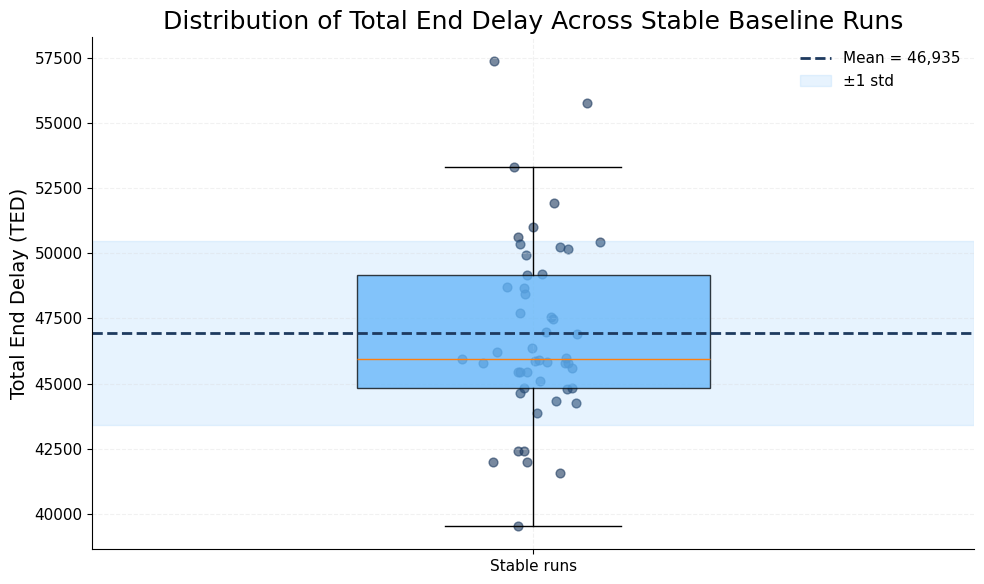

In [6]:
# ============================================================
# FIGURE 1 — TED Distribution (Stable Runs Only)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Enkel stabiele runs
stable_ted = baseline.loc[
    baseline["deadlock"] == 0,
    "TED_combined"
].dropna()

# Boxplot
bp = ax.boxplot(
    [stable_ted],
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bp["boxes"]:
    patch.set_facecolor(MAIN_COLOR)
    patch.set_alpha(0.75)

# Scatter overlay
x = np.random.normal(
    1,
    0.03,
    size=len(stable_ted)
)

ax.scatter(
    x,
    stable_ted,
    alpha=0.6,
    color=ACCENT_COLOR,
    s=40
)

# Mean + std
mean_ted = stable_ted.mean()
std_ted  = stable_ted.std()

ax.axhline(
    mean_ted,
    linestyle="--",
    linewidth=2,
    color=ACCENT_COLOR,
    label=f"Mean = {mean_ted:,.0f}"
)

ax.axhspan(
    mean_ted - std_ted,
    mean_ted + std_ted,
    alpha=0.15,
    color=MAIN_COLOR,
    label="±1 std"
)

# Labels
ax.set_xticks([1])
ax.set_xticklabels(["Stable runs"])

ax.set_ylabel("Total End Delay (TED)")
ax.set_title(
    "Distribution of Total End Delay Across Stable Baseline Runs"
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# EXTENDED BASELINE SUMMARY TABLE
# ============================================================

summary_cols = [
    "TED_combined",
    "TED_passenger",
    "TED_freight",
    "delay_ratio"
]

summary_rows = []

for col in summary_cols:

    series = baseline[col].dropna()

    row = {
        "Metric": col,
        "N": baseline["seed"].nunique(),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "CV": series.std() / series.mean(),
        "P5": series.quantile(0.05),
        "P95": series.quantile(0.95),
        "min": series.min(),
        "max": series.max(),
        "# deadlocks": baseline["deadlock"].sum()
    }

    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)

# formatting
summary_table = summary_table.round({
    "mean": 2,
    "median": 2,
    "std": 2,
    "CV": 3,
    "P5": 2,
    "P95": 2,
    "min": 2,
    "max": 2
})

display(summary_table)

,Metric,N,mean,median,std,CV,P5,P95,min,max,# deadlocks
0,TED_combined,50,46934.70,45940.50,3518.18,0.075,41974.98,52747.08,39534.60,57386.60,1
1,TED_passenger,50,37455.28,37559.70,1885.55,0.050,34445.74,40008.00,32086.80,41646.00,1
2,TED_freight,50,9479.42,8858.60,3137.01,0.331,6043.84,15618.88,4577.10,21682.60,1
3,delay_ratio,50,1.44,1.36,0.49,0.343,0.90,2.29,0.74,3.43,1


In [8]:
# ============================================================
# TRAIN TYPE CONTRIBUTION TABLE
# ============================================================

ted_cols = {
    "IC": "TED_IC",
    "L": "TED_L",
    "EURST": "TED_EURST",
    "ICE": "TED_ICE",
    "INT": "TED_INT",
    "Freight": "TED_freight"
}

train_counts = {
    "IC": 632,
    "L": 325,
    "EURST": 36,
    "ICE": 14,
    "INT": 21,
    "Freight": 182
}

total_mean_ted = baseline["TED_combined"].mean()

rows = []

for train_type, col in ted_cols.items():

    series = baseline[col].dropna() / train_counts[train_type]

    mean_val = series.mean()

    row = {
        "Type": train_type,
        "% of TED_combined": 100 * mean_val / total_mean_ted,
        "Mean TED": mean_val,
        "Median TED": series.median(),
        "Std TED": series.std(),
        "CV(TED)": series.std() / mean_val if mean_val != 0 else np.nan,
        "P5": series.quantile(0.05),
        "P95": series.quantile(0.95),
        "N": baseline["seed"].nunique(),
        "# deadlocks": baseline["deadlock"].sum()
    }

    rows.append(row)

train_type_table = pd.DataFrame(rows)

train_type_table = train_type_table.sort_values(
    "% of TED_combined",
    ascending=False
)

train_type_table = train_type_table.round({
    "% of TED_combined": 1,
    "Mean TED": 1,
    "Median TED": 1,
    "Std TED": 1,
    "CV(TED)": 3,
    "P5": 1,
    "P95": 1
})

display(train_type_table)

,Type,% of TED_combined,Mean TED,Median TED,Std TED,CV(TED),P5,P95,N,# deadlocks
1,L,0.1,61.8,61.6,2.5,0.040,58.4,65.7,50,1
4,INT,0.1,56.8,57.7,15.5,0.273,30.7,79.9,50,1
5,Freight,0.1,52.1,48.7,17.2,0.331,33.2,85.8,50,1
3,ICE,0.1,48.9,45.2,17.4,0.355,26.7,76.2,50,1
2,EURST,0.1,48.8,47.9,12.6,0.258,31.9,70.7,50,1
0,IC,0.0,21.7,21.8,2.3,0.108,17.7,25.3,50,1


In [9]:
# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

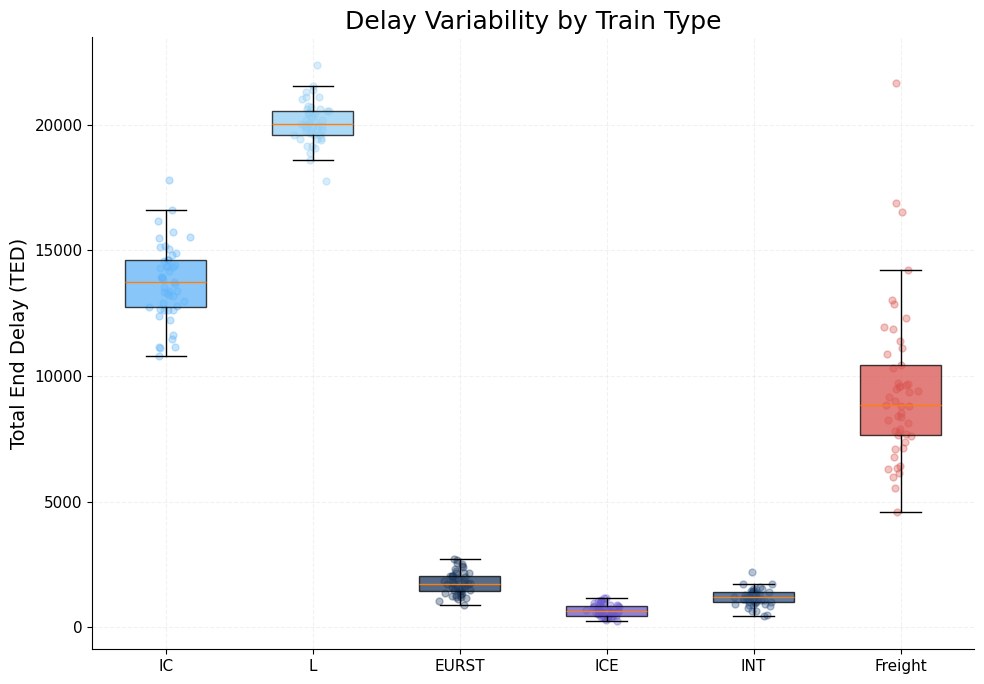

In [10]:
# ============================================================
# FIGURE — TED DISTRIBUTION PER TRAIN TYPE
# ============================================================

ted_cols = {
    "IC": "TED_IC",
    "L": "TED_L",
    "EURST": "TED_EURST",
    "ICE": "TED_ICE",
    "INT": "TED_INT",
    "Freight": "TED_freight"
}

fig, ax = plt.subplots(figsize=(10, 7))

positions = np.arange(1, len(ted_cols) + 1)

for i, (label, col) in enumerate(ted_cols.items(), start=1):

    values = baseline[col].dropna()

    bp = ax.boxplot(
        values,
        positions=[i],
        widths=0.55,
        patch_artist=True,
        showfliers=False
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(colors[label])
        patch.set_alpha(0.75)

    # jittered datapoints
    x = np.random.normal(i, 0.05, size=len(values))

    ax.scatter(
        x,
        values,
        alpha=0.35,
        s=25,
        color=colors[label]
    )

ax.set_xticks(positions)
ax.set_xticklabels(ted_cols.keys())

ax.set_ylabel("Total End Delay (TED)")
ax.set_title("Delay Variability by Train Type")

plt.tight_layout()
plt.show()

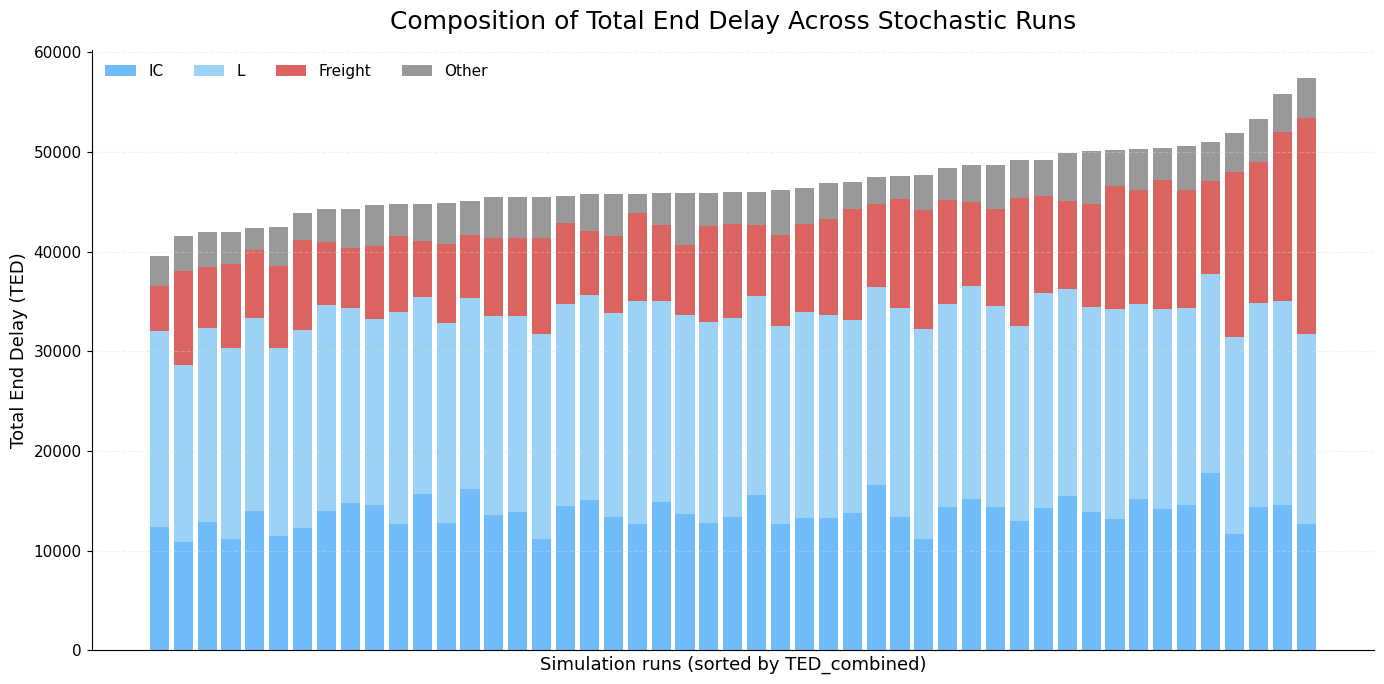

In [11]:
# ============================================================
# FIGURE B — Stacked Delay Composition per Seed
# Seeds sorted by total congestion
# ============================================================

# ------------------------------------------------------------
# Select columns
# ------------------------------------------------------------

plot_df = baseline[
    [
        "seed",
        "TED_combined",
        "TED_IC",
        "TED_L",
        "TED_freight",
        "TED_EURST",
        "TED_ICE",
        "TED_INT"
    ]
].copy()

# ------------------------------------------------------------
# Create "Other" category
# ------------------------------------------------------------

plot_df["TED_other"] = (
    plot_df["TED_EURST"]
    + plot_df["TED_ICE"]
    + plot_df["TED_INT"]
)

# ------------------------------------------------------------
# Sort by total delay
# ------------------------------------------------------------

plot_df = plot_df.sort_values("TED_combined").reset_index(drop=True)

# ------------------------------------------------------------
# X positions
# ------------------------------------------------------------

x = np.arange(len(plot_df))

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

# IC
ax.bar(
    x,
    plot_df["TED_IC"],
    label="IC",
    color=colors["IC"],
    alpha=0.9
)

# L
ax.bar(
    x,
    plot_df["TED_L"],
    bottom=plot_df["TED_IC"],
    label="L",
    color=colors["L"],
    alpha=0.9
)

# Freight
ax.bar(
    x,
    plot_df["TED_freight"],
    bottom=plot_df["TED_IC"] + plot_df["TED_L"],
    label="Freight",
    color=colors["Freight"],
    alpha=0.9
)

# Other
ax.bar(
    x,
    plot_df["TED_other"],
    bottom=(
        plot_df["TED_IC"]
        + plot_df["TED_L"]
        + plot_df["TED_freight"]
    ),
    label="Other",
    color="#808080",
    alpha=0.8
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Simulation runs (sorted by TED_combined)",
    fontsize=13
)

ax.set_ylabel(
    "Total End Delay (TED)",
    fontsize=13
)

ax.set_title(
    "Composition of Total End Delay Across Stochastic Runs",
    fontsize=18,
    pad=15
)

# Remove cluttered seed labels
ax.set_xticks([])

# Legend
ax.legend(
    frameon=False,
    ncol=4,
    loc="upper left"
)

plt.tight_layout()
plt.show()

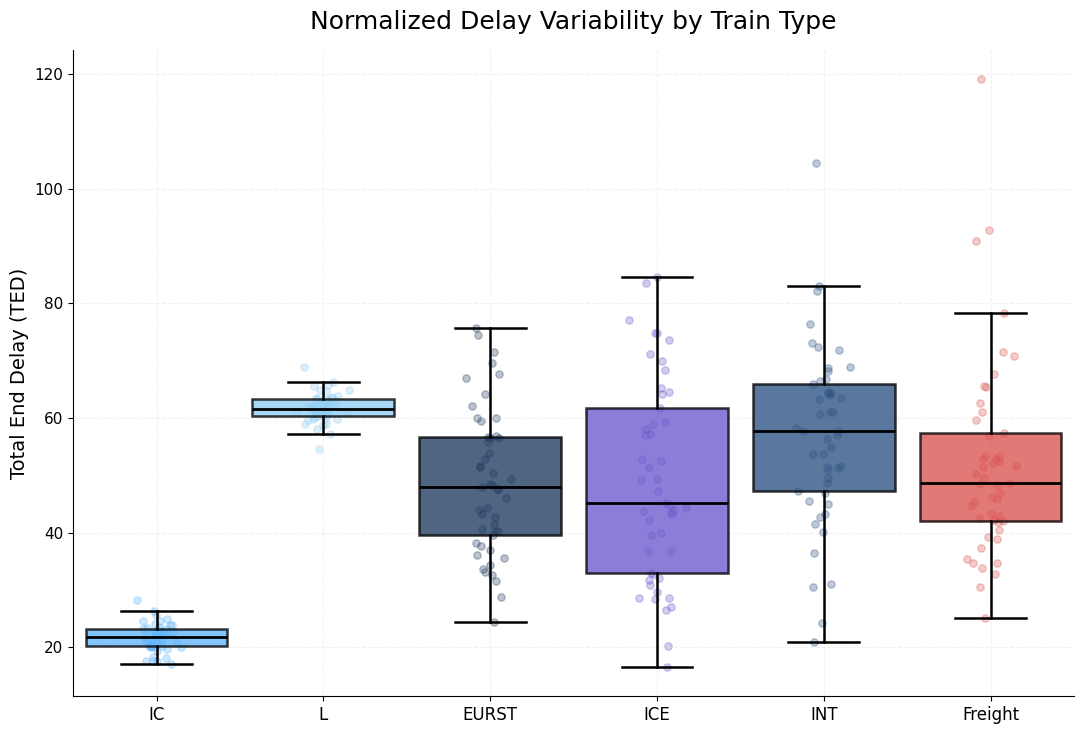

In [17]:
# ============================================================
# FIGURE — TED DISTRIBUTION PER TRAIN TYPE
# ============================================================

ted_cols = {
    "IC": "TED_IC",
    "L": "TED_L",
    "EURST": "TED_EURST",
    "ICE": "TED_ICE",
    "INT": "TED_INT",
    "Freight": "TED_freight"
}

fig, ax = plt.subplots(figsize=(11, 7.5))

positions = np.arange(1, len(ted_cols) + 1)

for i, (label, col) in enumerate(ted_cols.items(), start=1):

    values = baseline[col].dropna() / train_counts[label]

    bp = ax.boxplot(
        values,
        positions=[i],
        widths=0.85,              # groter gemaakt
        patch_artist=True,
        showfliers=False,
        medianprops=dict(
            color="black",
            linewidth=2
        ),
        whiskerprops=dict(
            linewidth=1.8
        ),
        capprops=dict(
            linewidth=1.8
        ),
        boxprops=dict(
            linewidth=1.8
        )
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(colors[label])
        patch.set_alpha(0.78)

    # jittered datapoints
    x = np.random.normal(i, 0.06, size=len(values))

    ax.scatter(
        x,
        values,
        alpha=0.30,
        s=28,
        color=colors[label]
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    ted_cols.keys(),
    fontsize=12
)

ax.set_ylabel("Total End Delay (TED)", fontsize=14)

ax.set_title(
    "Normalized Delay Variability by Train Type",
    fontsize=18,
    pad=15
)

plt.tight_layout()
plt.show()

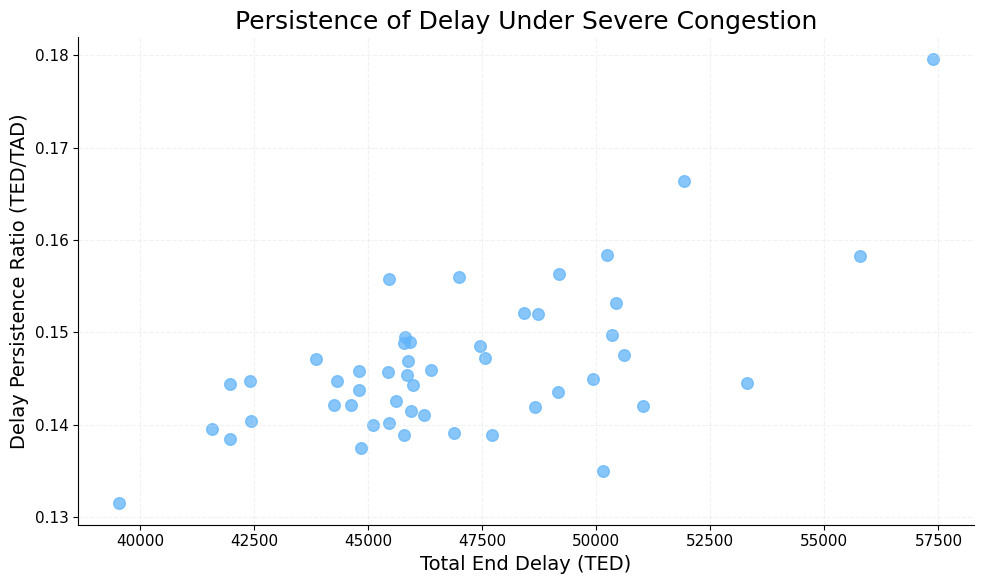

In [13]:
plot_df = baseline.copy()

plot_df["persistence"] = (
    plot_df["TED_combined"]
    / plot_df["TAD_combined"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_df["TED_combined"],
    plot_df["persistence"],
    color=MAIN_COLOR,
    alpha=0.75,
    s=70
)

ax.set_xlabel("Total End Delay (TED)")
ax.set_ylabel("Delay Persistence Ratio (TED/TAD)")

ax.set_title(
    "Persistence of Delay Under Severe Congestion"
)

plt.tight_layout()
plt.show()

In [14]:
baseline.columns

Index(['seed', 'phase', 'strategy_type', 'periodic_rf', 'event_driven_rf',
       'controller_freq', 'threshold_conf', 'priority', 'weight_passenger',
       'weight_freight', 'gamma', 'upgrade', 'w_IC', 'w_L', 'w_S', 'w_EURST',
       'w_ICE', 'w_INT', 'w_freight', 'objective', 'freight_pct',
       'mc_delay_per_train', 'solver_timeout', 'total_solve_time',
       'n_rescheduled', 'n_fcfs_fallback', 'n_skipped', 'infeasible_run',
       'deadlock', 'TED_passenger', 'TED_freight', 'TED_combined',
       'TAD_passenger', 'TAD_freight', 'TAD_combined', 'delay_ratio',
       'n_passenger', 'n_freight', 'TED_IC', 'TED_L', 'TED_S', 'TED_EURST',
       'TED_ICE', 'TED_INT', 'n_IC', 'n_L', 'n_S', 'n_EURST', 'n_ICE', 'n_INT',
       'n_unfinished_IC', 'n_unfinished_L', 'n_unfinished_S',
       'n_unfinished_EURST', 'n_unfinished_ICE', 'n_unfinished_INT',
       'n_unfinished_freight', 'n_unfinished_total', 'config'],
      dtype='str')

In [15]:
# ============================================================
# CORRECT RECOVERY TABLE
# ============================================================

rows = []

# ------------------------------------------------------------
# Passenger
# ------------------------------------------------------------

passenger_recovery = 1 - (
    baseline["TED_passenger"]
    / baseline["TAD_passenger"]
)

rows.append({

    "Type": "Passenger",

    # TAD
    "Mean TAD": baseline["TAD_passenger"].mean(),
    "Std TAD": baseline["TAD_passenger"].std(),

    # TED
    "Mean TED": baseline["TED_passenger"].mean(),
    "Std TED": baseline["TED_passenger"].std(),

    # Recovery
    "Mean Recovery": passenger_recovery.mean(),
    "Std Recovery": passenger_recovery.std(),
    "CV Recovery": (
        passenger_recovery.std()
        / passenger_recovery.mean()
    ),

    "P5": passenger_recovery.quantile(0.05),
    "P95": passenger_recovery.quantile(0.95)
})

# ------------------------------------------------------------
# Freight
# ------------------------------------------------------------

freight_recovery = 1 - (
    baseline["TED_freight"]
    / baseline["TAD_freight"]
)

rows.append({

    "Type": "Freight",

    # TAD
    "Mean TAD": baseline["TAD_freight"].mean(),
    "Std TAD": baseline["TAD_freight"].std(),

    # TED
    "Mean TED": baseline["TED_freight"].mean(),
    "Std TED": baseline["TED_freight"].std(),

    # Recovery
    "Mean Recovery": freight_recovery.mean(),
    "Std Recovery": freight_recovery.std(),
    "CV Recovery": (
        freight_recovery.std()
        / freight_recovery.mean()
    ),

    "P5": freight_recovery.quantile(0.05),
    "P95": freight_recovery.quantile(0.95)
})

recovery_table = pd.DataFrame(rows)

recovery_table = recovery_table.round(3)

display(recovery_table)

,Type,Mean TAD,Std TAD,Mean TED,Std TED,Mean Recovery,Std Recovery,CV Recovery,P5,P95
0,Passenger,299091.312,13727.678,37455.280,1885.555,0.875,0.003,0.004,0.870,0.88
1,Freight,21640.020,11779.946,9479.422,3137.012,0.495,0.162,0.327,0.258,0.74


In [16]:
# ============================================================
# OPTIONAL — CORRELATION VALUE
# ============================================================

corr = baseline["TAD_freight"].corr(
    baseline["TAD_passenger"]
)

print(f"Correlation between freight and passenger delay: {corr:.3f}")

Correlation between freight and passenger delay: 0.091
